# Feature importance for a QNN: Q-LIME vs TN-SHAP-Q

**Standalone, self-contained notebook** (only `numpy`, `scipy`, `scikit-learn`, `matplotlib`,
`qiskit`; no other files, no absolute paths). Runs top-to-bottom.

A single-$R_Y$ QNN is **exactly multilinear** in the lifted features $[1,\cos x_i,\sin x_i]$, so when we
mask features against a baseline, the multilinear extension $F(z)$ of the resulting cooperative game is
the function the circuit computes. The first-order Shapley value is the Owen diagonal integral

$$\phi_i=\int_0^1 \partial_i F(t\mathbf 1)\,dt,\qquad
\partial_i F(t\mathbf 1)=F(z_i{=}1,z_{-i}{=}t)-F(z_i{=}0,z_{-i}{=}t),$$

which $M$-point Gauss--Legendre quadrature evaluates **exactly once $M\ge\lceil d/2\rceil$**, using
$2dM$ evaluations of the extension. We compare **TN-SHAP-Q (Owen)** against **Q-LIME** (a local linear
surrogate) on **accuracy vs. the exact $2^d$-enumeration Shapley** and on **evaluation count**.

In [1]:
import math
from functools import reduce
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp, Operator
np.set_printoptions(precision=4, suppress=True)
print("imports OK")

imports OK


## 1. A single-$R_Y$ QNN

Encode each feature by $R_Y(x_i)$, then $L{=}2$ variational layers ($R_Y(w)$ on every qubit + a CX
ring); readout $P(\text{class }1)=(1-\langle Z_0\rangle)/2$.

In [2]:
class QNN:
    def __init__(self, n_features, n_layers=2, seed=0):
        self.nq = n_features; self.L = n_layers
        self.weights = np.random.default_rng(seed).uniform(0, 2*np.pi, n_layers*n_features)
        self.n_weights = n_layers*n_features
        self.Z0 = SparsePauliOp.from_list([("Z" + "I"*(n_features-1), 1.0)])
    def _circuit(self, x, w):
        qc = QuantumCircuit(self.nq)
        for q in range(self.nq): qc.ry(float(x[q]), q)
        k = 0
        for _ in range(self.L):
            for q in range(self.nq): qc.ry(float(w[k]), q); k += 1
            for q in range(self.nq): qc.cx(q, (q+1) % self.nq)
        return qc
    def prob1(self, x, w=None):
        w = self.weights if w is None else w
        z0 = float(np.real(Statevector(self._circuit(np.asarray(x, float), w)).expectation_value(self.Z0)))
        return float((1 - z0) / 2)
    def predict(self, X): return np.array([self.prob1(x) for x in X])
    def fit(self, X, y, epochs=80, lr=0.12, batch=32, seed=0):
        rng = np.random.default_rng(seed); X = np.asarray(X, float); y = np.asarray(y, float); n = len(X)
        m1 = np.zeros(self.n_weights); v1 = np.zeros(self.n_weights); t = 0; b1, b2, eps = 0.9, 0.999, 1e-8
        for _ in range(epochs):
            idx = rng.permutation(n)[:batch]; grad = np.zeros(self.n_weights)
            for i in idx:
                p = np.clip(self.prob1(X[i]), 1e-6, 1-1e-6); dL = (p - y[i])/(p*(1-p))
                for j in range(self.n_weights):
                    wp = self.weights.copy(); wp[j] += np.pi/2
                    wm = self.weights.copy(); wm[j] -= np.pi/2
                    grad[j] += dL*(self.prob1(X[i], wp) - self.prob1(X[i], wm))/2
            grad /= len(idx); t += 1
            m1 = b1*m1 + (1-b1)*grad; v1 = b2*v1 + (1-b2)*grad**2
            self.weights -= lr*(m1/(1-b1**t))/(np.sqrt(v1/(1-b2**t)) + eps)
        return self
print("QNN defined")

QNN defined


## 2. Train on Iris (setosa vs versicolor); choose a baseline and instances

In [3]:
iris = load_iris(); msk = iris.target < 2
D = 4
Xf = MinMaxScaler((0, np.pi)).fit_transform(iris.data[msk][:, :D])
yf = iris.target[msk].astype(float)
qnn = QNN(n_features=D, n_layers=2, seed=0).fit(Xf, yf, epochs=80, lr=0.15, batch=32, seed=0)
acc = float(np.mean((qnn.predict(Xf) > 0.5) == yf))
baseline = Xf.mean(0)
cohort = [(int(i), Xf[i]) for i in np.random.default_rng(123).choice(len(Xf), size=4, replace=False)]
print(f"d={D} features, train accuracy = {acc:.3f}")
print("baseline (feature means):", np.round(baseline, 3))
print("instances:", [i for i, _ in cohort])

d=4 features, train accuracy = 0.980
baseline (feature means): [1.363 1.439 1.426 1.268]
instances: [66, 58, 1, 5]


## 3. Exact feature Shapley (ground truth, $2^d$ evaluations)

Feature game $v_x(S)=P(\text{class }1\mid x_S)$: features outside $S$ take their baseline value.

In [4]:
def feature_table(qnn, x, baseline):
    n = qnn.nq
    return {mask: qnn.prob1(np.array([x[i] if (mask >> i) & 1 else baseline[i] for i in range(n)]))
            for mask in range(1 << n)}

def exact_shapley(tab, n):
    phi = np.zeros(n); fact = [math.factorial(k) for k in range(n+1)]
    for i in range(n):
        others = [j for j in range(n) if j != i]
        for r in range(len(others)+1):
            wgt = fact[r]*fact[n-r-1]/fact[n]
            for S in combinations(others, r):
                mS = 0
                for j in S: mS |= 1 << j
                phi[i] += wgt*(tab[mS | (1 << i)] - tab[mS])
    return phi

tables = [feature_table(qnn, x, baseline) for _, x in cohort]
phi_exact = [exact_shapley(t, D) for t in tables]
print("exact Shapley (instance 0):", phi_exact[0], " | evaluations = 2^d =", 1 << D)

exact Shapley (instance 0): [-0.0011  0.0261  0.2979  0.1031]  | evaluations = 2^d = 16


## 4. TN-SHAP-Q: Owen multilinear-extension Shapley

$\rho(x_i)=\tfrac12(I+\cos x_i Z+\sin x_i X)$. The extension value $F(z)$ is evaluated at the
interpolation point (feature $i$ at coordinate $z_i$ between baseline and instance). The diagonal
finite difference is exact by multilinearity, and $M$-node Gauss--Legendre is exact once
$M\ge\lceil d/2\rceil$ ($2dM$ extension evaluations).

In [5]:
I2 = np.eye(2, dtype=complex)
Xm = np.array([[0, 1], [1, 0]], complex); Zm = np.array([[1, 0], [0, -1]], complex)
def rho(theta): return 0.5*(I2 + np.cos(theta)*Zm + np.sin(theta)*Xm)
def kron_q(mats): return reduce(np.kron, [mats[q] for q in range(len(mats)-1, -1, -1)])
def layers_U(qnn):
    qc = QuantumCircuit(qnn.nq); k = 0
    for _ in range(qnn.L):
        for q in range(qnn.nq): qc.ry(float(qnn.weights[k]), q); k += 1
        for q in range(qnn.nq): qc.cx(q, (q+1) % qnn.nq)
    return Operator(qc).data

def owen_feature_shapley(qnn, x, baseline, M):
    n = qnn.nq
    nodes, wts = np.polynomial.legendre.leggauss(M); t = 0.5*(nodes+1); w = 0.5*wts
    U = layers_U(qnn); Ud = U.conj().T; Z0 = Operator(qnn.Z0).data
    rw = [rho(baseline[j]) for j in range(n)]; dr = [rho(x[j]) - rho(baseline[j]) for j in range(n)]
    def F(ops):  # extension value: per-feature input interpolated by its coordinate
        R = kron_q(ops); return 0.5*(1 - float(np.real(np.trace(Z0 @ (U @ R @ Ud)))))
    phi = np.zeros(n)
    for i in range(n):
        acc = 0.0
        for tm, wm in zip(t, w):
            others = [rw[j] + tm*dr[j] for j in range(n)]
            on = [(rw[j] + dr[j]) if j == i else others[j] for j in range(n)]
            off = [rw[j] if j == i else others[j] for j in range(n)]
            acc += wm*(F(on) - F(off))
        phi[i] = acc
    return phi, 2*n*M

for M in (1, 2, 4):
    err = max(np.max(np.abs(owen_feature_shapley(qnn, x, baseline, M)[0] - phi_exact[k]))
              for k, (_, x) in enumerate(cohort))
    print(f"Owen M={M} (2dM={2*D*M:2d} evals): max|Owen - exact| over cohort = {err:.2e}")
phi_owen = [owen_feature_shapley(qnn, x, baseline, 2)[0] for _, x in cohort]
print("-> M=1 inexact, M>=ceil(d/2)=2 reaches machine precision")

Owen M=1 (2dM= 8 evals): max|Owen - exact| over cohort = 1.82e-03
Owen M=2 (2dM=16 evals): max|Owen - exact| over cohort = 2.22e-16
Owen M=4 (2dM=32 evals): max|Owen - exact| over cohort = 2.64e-16


-> M=1 inexact, M>=ceil(d/2)=2 reaches machine precision


## 5. Q-LIME (local linear surrogate)

Sample $M$ binary feature masks, weight by an exponential kernel in Hamming distance, fit a weighted ridge; the coefficients are the attributions. Each sample is one masked-circuit evaluation, so the evaluation count is $M$.

**Q-LIME returns local-linear coefficients, not Shapley values.** They live on a different scale and need not match the exact Shapley magnitudes, so an MAE-against-exact-Shapley is not the right yardstick. We therefore compare Q-LIME and TN-SHAP-Q **only on the feature ranking they induce** (Spearman, Kendall $\tau$, and top-1 agreement).

In [6]:
def qlime(qnn, x, baseline, M, rng, kernel_width=0.35, lam=1e-3):
    n = qnn.nq
    Z = rng.integers(0, 2, size=(M, n)).astype(int); Z[0] = 1; Z[1] = 0
    y = np.array([qnn.prob1(np.where(Z[k] == 1, x, baseline)) for k in range(M)])
    dist = np.sum(1 - Z, axis=1)/np.sqrt(n); wk = np.exp(-(dist**2)/(kernel_width**2 + 1e-12))
    A = np.hstack([np.ones((M, 1)), Z]); reg = lam*np.eye(n+1); reg[0, 0] = 0.0
    beta = np.linalg.solve(A.T @ (wk[:, None]*A) + reg, A.T @ (wk*y))
    return beta[1:], M
print("Q-LIME beta (instance 0, M=256):", qlime(qnn, cohort[0][1], baseline, 256, np.random.default_rng(0))[0])

Q-LIME beta (instance 0, M=256): [-0.0028  0.0214  0.2424  0.054 ]


## 6. Feature importances (instance 0): exact vs TN-SHAP-Q

TN-SHAP-Q *is* a Shapley method, so we check it against exact enumeration (machine precision). Q-LIME is compared separately, on ranking only (next section).

 feature     exact   TN-SHAP-Q    Q-LIME
       0   -0.0011     -0.0011   -0.0028
       1    0.0261      0.0261    0.0214
       2    0.2979      0.2979    0.2423
       3    0.1031      0.1031    0.0539

TN-SHAP-Q vs exact Shapley  : MAE=5.35e-17  cosine=1.0000
Q-LIME    vs TN-SHAP-Q rank : Spearman=1.000  Kendall=1.000  top-1 match


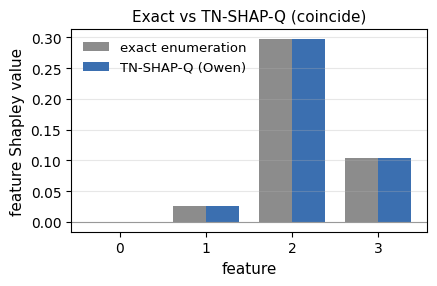

In [7]:
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9.5})

def cosine(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    return float(a @ b / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-30))
def spearman(a, b):
    ra = np.argsort(np.argsort(a)).astype(float); rb = np.argsort(np.argsort(b)).astype(float)
    ra -= ra.mean(); rb -= rb.mean(); d = np.linalg.norm(ra)*np.linalg.norm(rb)
    return float(ra @ rb / d) if d else 1.0
def kendall(a, b):
    n = len(a); c = d = 0
    for i in range(n):
        for j in range(i+1, n):
            s = np.sign(a[i]-a[j])*np.sign(b[i]-b[j])
            c += int(s > 0); d += int(s < 0)
    return (c-d)/(c+d) if (c+d) else 1.0

pe = phi_exact[0]; po = phi_owen[0]
pq = qlime(qnn, cohort[0][1], baseline, 256, np.random.default_rng(1))[0]
print(f"{'feature':>8} {'exact':>9} {'TN-SHAP-Q':>11} {'Q-LIME':>9}")
for i in range(D):
    print(f"{i:>8} {pe[i]:>9.4f} {po[i]:>11.4f} {pq[i]:>9.4f}")
# TN-SHAP-Q is a Shapley method -> compare *values* to exact Shapley
print(f"\nTN-SHAP-Q vs exact Shapley  : MAE={np.mean(np.abs(po-pe)):.2e}  cosine={cosine(po,pe):.4f}")
# Q-LIME is a local-linear attribution (not Shapley) -> compare *ranking* only
print(f"Q-LIME    vs TN-SHAP-Q rank : Spearman={spearman(pq,po):.3f}  Kendall={kendall(pq,po):.3f}  "
      f"top-1 {'match' if np.argmax(pq)==np.argmax(po) else 'differ'}")

# Bar chart: exact vs TN-SHAP-Q (they coincide -> exactness)
fig, ax = plt.subplots(figsize=(4.5, 3.0))
xb = np.arange(D); wid = 0.38
ax.bar(xb - wid/2, pe, wid, color='0.55', label='exact enumeration')
ax.bar(xb + wid/2, po, wid, color='#3b6fb0', label='TN-SHAP-Q (Owen)')
ax.axhline(0, color='0.6', lw=0.8); ax.set_xticks(xb)
ax.set_xlabel('feature'); ax.set_ylabel('feature Shapley value')
ax.set_title('Exact vs TN-SHAP-Q (coincide)')
ax.legend(frameon=False); ax.grid(alpha=0.3, axis='y'); fig.tight_layout()
fig.savefig('feature_importance_bars.pdf', bbox_inches='tight')
fig.savefig('feature_importance_bars.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. Q-LIME vs TN-SHAP-Q: feature ranking only

Since Q-LIME does not produce Shapley values, we sweep its perturbation budget and measure how well its **feature ranking** agrees with TN-SHAP-Q (= exact Shapley): Spearman, Kendall $\tau$, and top-1 agreement, averaged over the cohort and seeds. The agreement **saturates below 1** no matter how many perturbations are drawn -- a local-linear *ranking* bias, not a sampling artifact.

budget  : [16, 32, 64, 128, 256, 512]
Spearman: ['0.78', '0.82', '0.80', '0.80', '0.80', '0.80']
Kendall : ['0.71', '0.78', '0.75', '0.75', '0.75', '0.75']
top-1   : ['0.59', '0.72', '0.75', '0.75', '0.75', '0.75']


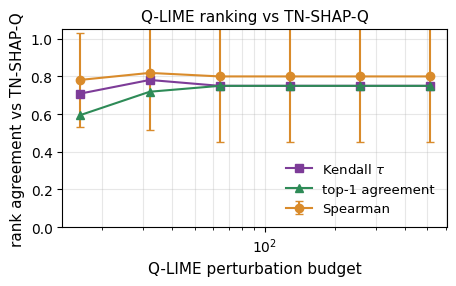

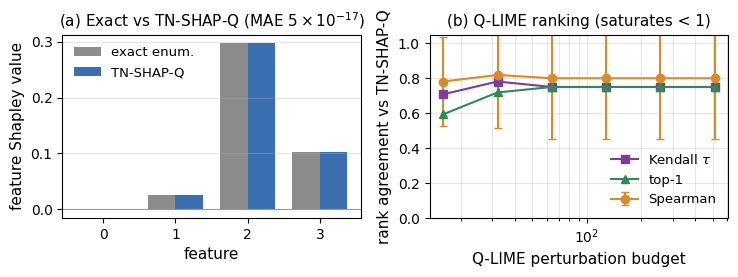

In [8]:
M_QLIME = [16, 32, 64, 128, 256, 512]; SEEDS = 8
sp_mean, sp_std, kt_mean, t1_mean = [], [], [], []
for M in M_QLIME:
    sps, kts, t1 = [], [], []
    for s in range(SEEDS):
        rng = np.random.default_rng(100 + 7*M + s)
        for k, (_, x) in enumerate(cohort):
            b, _ = qlime(qnn, x, baseline, M, rng); ref = phi_owen[k]   # ref = TN-SHAP-Q == exact Shapley
            sps.append(spearman(b, ref)); kts.append(kendall(b, ref))
            t1.append(float(np.argmax(b) == np.argmax(ref)))
    sp_mean.append(float(np.mean(sps))); sp_std.append(float(np.std(sps)))
    kt_mean.append(float(np.mean(kts))); t1_mean.append(float(np.mean(t1)))
print('budget  :', M_QLIME)
print('Spearman:', [f'{v:.2f}' for v in sp_mean])
print('Kendall :', [f'{v:.2f}' for v in kt_mean])
print('top-1   :', [f'{v:.2f}' for v in t1_mean])

# standalone ranking figure
fig, ax = plt.subplots(figsize=(4.7, 3.0))
ax.errorbar(M_QLIME, sp_mean, yerr=sp_std, marker='o', capsize=3, color='#d98b2b', label='Spearman')
ax.plot(M_QLIME, kt_mean, marker='s', color='#7d3c98', label=r'Kendall $\tau$')
ax.plot(M_QLIME, t1_mean, marker='^', color='#2e8b57', label='top-1 agreement')
ax.set_xscale('log'); ax.set_ylim(0, 1.05)
ax.set_xlabel('Q-LIME perturbation budget'); ax.set_ylabel('rank agreement vs TN-SHAP-Q')
ax.set_title('Q-LIME ranking vs TN-SHAP-Q')
ax.grid(alpha=0.3, which='both'); ax.legend(frameon=False, loc='lower right'); fig.tight_layout()
fig.savefig('qlime_vs_tnshapq_ranking.pdf', bbox_inches='tight')
fig.savefig('qlime_vs_tnshapq_ranking.png', dpi=150, bbox_inches='tight'); plt.show()

# combined compact 2-panel figure for the paper
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.6, 2.9))
xb = np.arange(D); wid = 0.38
a1.bar(xb - wid/2, pe, wid, color='0.55', label='exact enum.')
a1.bar(xb + wid/2, po, wid, color='#3b6fb0', label='TN-SHAP-Q')
a1.axhline(0, color='0.6', lw=0.8); a1.set_xticks(xb)
a1.set_xlabel('feature'); a1.set_ylabel('feature Shapley value')
a1.set_title(r'(a) Exact vs TN-SHAP-Q (MAE $5\times10^{-17}$)')
a1.legend(frameon=False); a1.grid(alpha=0.3, axis='y')
a2.errorbar(M_QLIME, sp_mean, yerr=sp_std, marker='o', capsize=3, color='#d98b2b', label='Spearman')
a2.plot(M_QLIME, kt_mean, marker='s', color='#7d3c98', label=r'Kendall $\tau$')
a2.plot(M_QLIME, t1_mean, marker='^', color='#2e8b57', label='top-1')
a2.set_xscale('log'); a2.set_ylim(0, 1.05)
a2.set_xlabel('Q-LIME perturbation budget'); a2.set_ylabel('rank agreement vs TN-SHAP-Q')
a2.set_title('(b) Q-LIME ranking (saturates < 1)')
a2.grid(alpha=0.3, which='both'); a2.legend(frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig('feature_attribution.pdf', bbox_inches='tight')
fig.savefig('feature_attribution.png', dpi=150, bbox_inches='tight'); plt.show()

## 8. Summary

* **TN-SHAP-Q is exact:** it reproduces the exact feature Shapley values to machine precision ($\sim10^{-16}$) once $M\ge\lceil d/2\rceil$ ($M{=}1$ is inexact $\to$ confirms the threshold), at $2dM{=}16$ extension evaluations.
* **Q-LIME is a local-linear attribution, not a Shapley value:** we therefore compare it to TN-SHAP-Q on the **feature ranking** only. Its rank agreement (Spearman $\approx0.8$, top-1 $\approx0.75$) **saturates below 1** regardless of the perturbation budget -- a local-linear ranking bias, not a sampling artifact.

*Caveat:* TN-SHAP-Q's evaluations are values of the multilinear extension (interpolated inputs), while Q-LIME evaluates ordinary masked circuits; we compare Shapley exactness (TN-SHAP-Q) and feature ranking (Q-LIME).